# 02b. Репрезентативность inner join

Проверяем, является ли `joined_inner` (лоты со сделками) репрезентативным подмножеством `joined_left` (все лоты прайса) по категориальным признакам.

**Два подхода:**
1. Визуальное сравнение распределений категориальных признаков.
2. CatBoost-тест: если модель, предсказывающая `in_inner` (0/1), даёт ROC-AUC ≈ 0.5 — выборка репрезентативна.

**Признаки для теста:** `project_class_price`, `region_price`, `room_count_price`, `district_price`, `premises_type_price`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import JOINED_INNER_PARQUET, JOINED_LEFT_PARQUET

CAT_FEATURES = [
    "project_class_price",
    "region_price",
    "room_count_price",
    "district_price",
    "premises_type_price",
]

import matplotlib as mpl

# Visual style
C1, C2, C3 = "#2C7BB6", "#D7542B", "#2D9E5F"
PALETTE     = (C1, C2, C3, "#7B4F9E", "#E8B84B", "#5BB8C7",
               "#937860", "#DA8BC3", "#8C8C8C", "#CCB974")
plt.rcParams.update({
    "figure.figsize":    (10, 5),
    "figure.dpi":        150,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.8,
    "legend.edgecolor":  "0.8",
    "axes.spines.right": False,
    "axes.spines.top":   False,
    "axes.grid":         True,
    "axes.grid.axis":    "both",
    "grid.alpha":        0.3,
    "grid.linewidth":    0.5,
    "lines.linewidth":   1.8,
    "lines.markersize":  5,
    "axes.prop_cycle":   mpl.cycler("color", list(PALETTE)),
})

# Output dir
FIG_DIR = REPO_ROOT / "reports" / "figures" / "02b_representativeness"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

Для сравнения берём **один снэпшот на юнит** (последний по дате) — иначе лот из 20 срезов перевесит лот из 2 срезов.

In [2]:
left  = pd.read_parquet(JOINED_LEFT_PARQUET)
inner = pd.read_parquet(JOINED_INNER_PARQUET)

print(f"left:  {left.shape}")
print(f"inner: {inner.shape}")

inner_keys = set(inner["unit_match_key"].unique())

# Один снэпшот на юнит — последний по file_date
left_units = (
    left
    .assign(_fd=pd.to_datetime(left["file_date"], dayfirst=True, errors="coerce"))
    .sort_values("_fd")
    .drop_duplicates("unit_match_key", keep="last")
    .drop(columns="_fd")
    .reset_index(drop=True)
)
left_units["in_inner"] = left_units["unit_match_key"].isin(inner_keys).astype(int)

n_total = len(left_units)
n_sold  = left_units["in_inner"].sum()
print(f"\nУникальных юнитов в left:  {n_total:,}")
print(f"Из них есть в inner (=1):  {n_sold:,}  ({100 * n_sold / n_total:.1f}%)")
print(f"Только в left   (=0):      {n_total - n_sold:,}  ({100 * (n_total - n_sold) / n_total:.1f}%)")

left:  (4659378, 94)
inner: (914441, 94)



Уникальных юнитов в left:  882,647
Из них есть в inner (=1):  183,578  (20.8%)
Только в left   (=0):      699,069  (79.2%)


## 2. Сравнение распределений категориальных признаков

Для каждого признака — нормированное распределение в группах `in_inner=0` (непроданные) и `in_inner=1` (проданные).
`district_price` обрезан до топ-20 значений для читаемости.

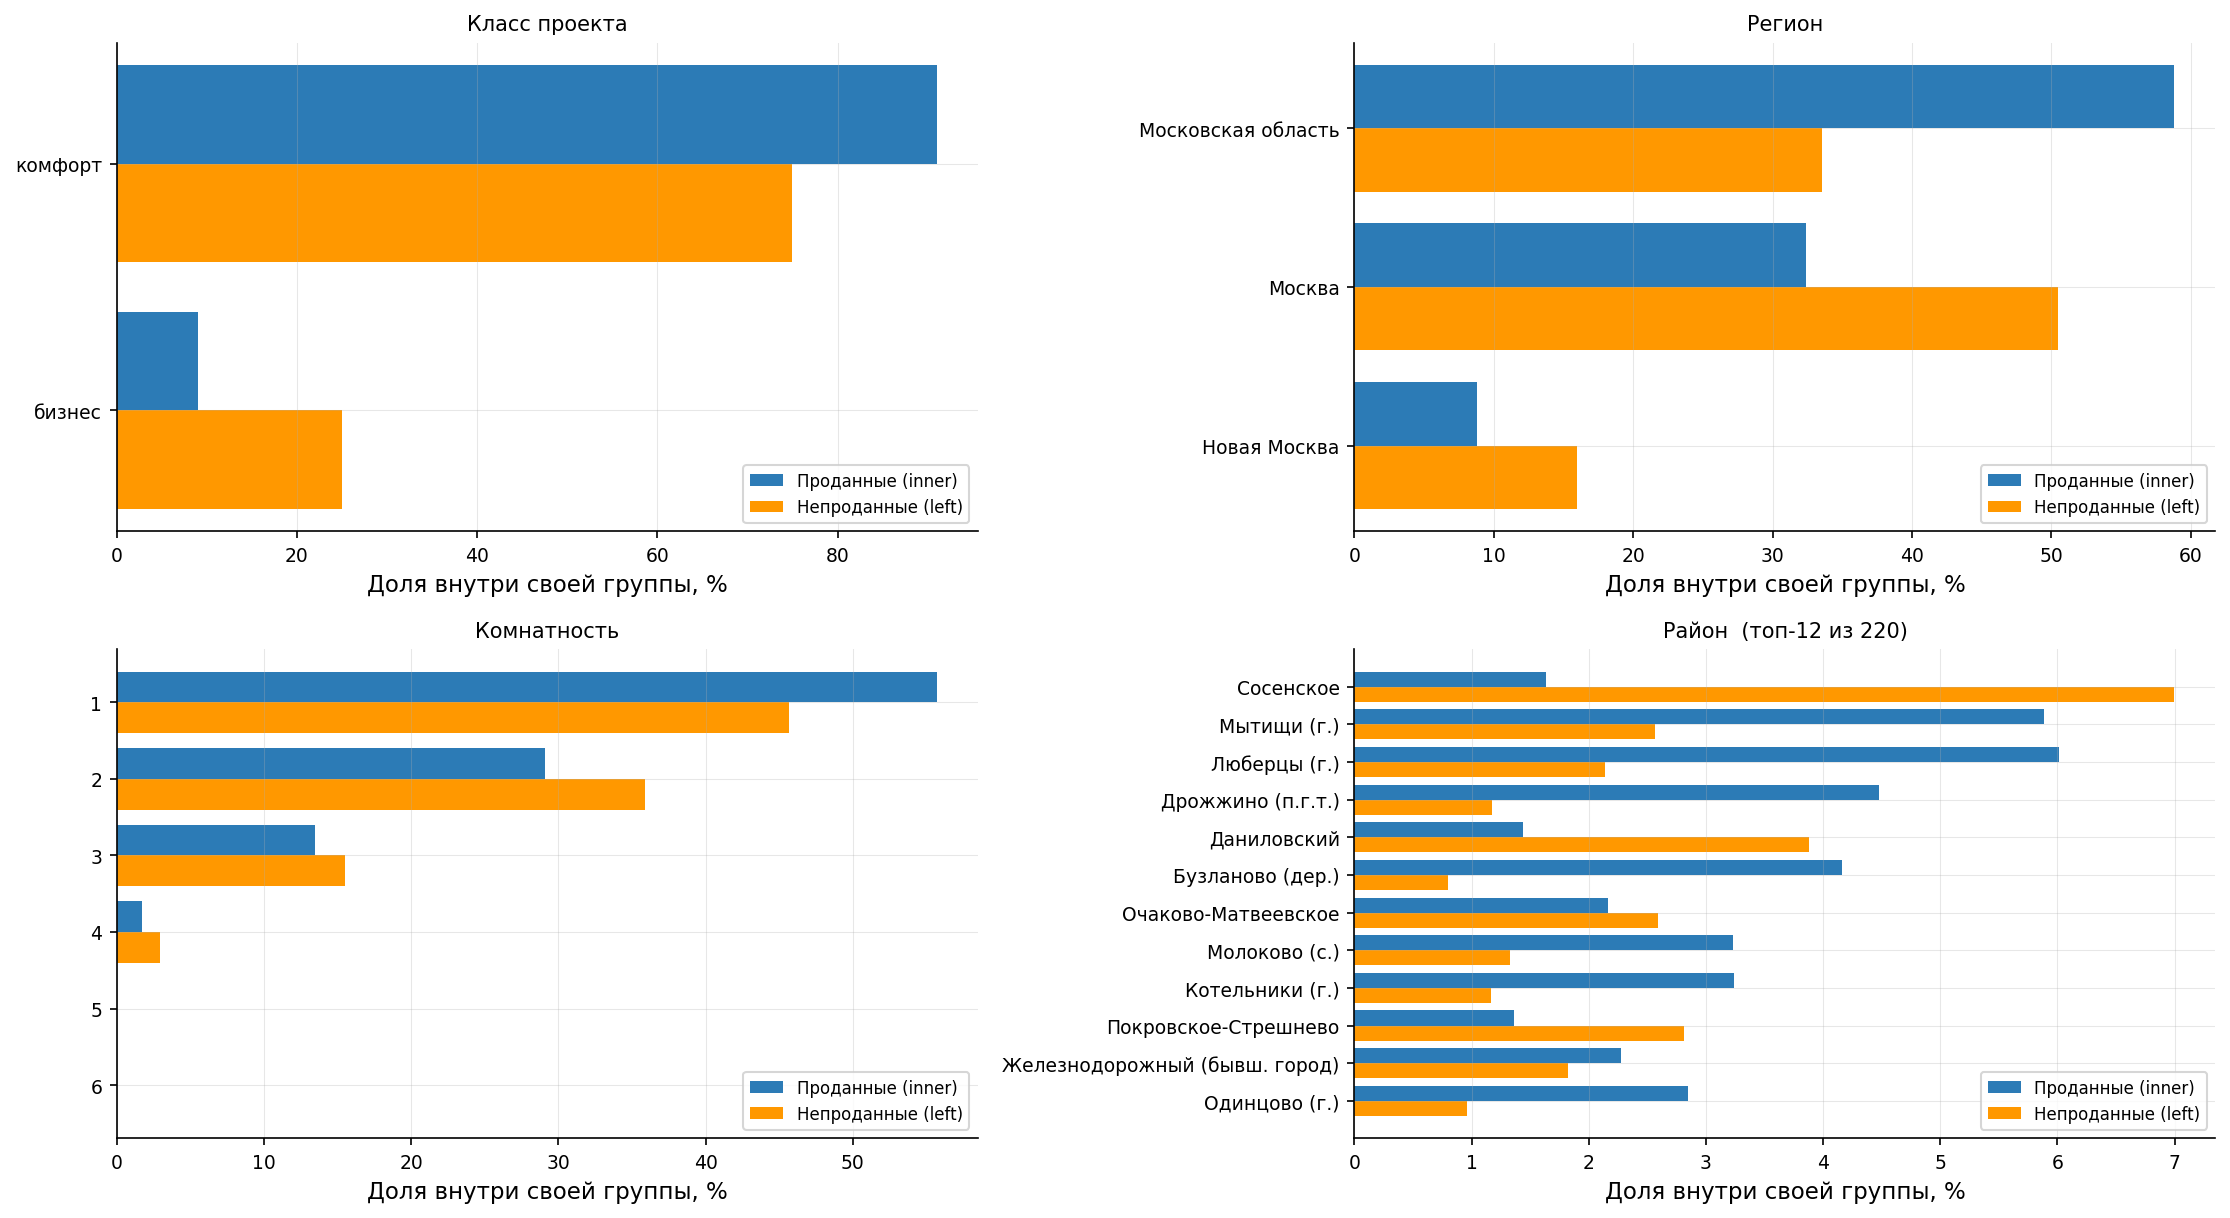

In [3]:
import numpy as np

# Читаемые русские подписи признаков
LABELS_RU = {
    "project_class_price": "Класс проекта",
    "region_price":        "Регион",
    "room_count_price":    "Комнатность",
    "district_price":      "Район",
    # "premises_type_price": "Тип помещения",
}
TOP_N = 12  # для многокатегорийных признаков (район и т.п.) — топ-N по суммарной доле

available = list(LABELS_RU.keys())
n = len(available)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, available):
    sold   = left_units.loc[left_units["in_inner"] == 1, col].value_counts(normalize=True) * 100
    unsold = left_units.loc[left_units["in_inner"] == 0, col].value_counts(normalize=True) * 100
    dfp = pd.concat(
        [sold.rename("Проданные (inner)"), unsold.rename("Непроданные (left)")], axis=1
    ).fillna(0)

    n_cat = len(dfp)
    dfp = dfp.assign(_o=dfp.sum(axis=1)).sort_values("_o", ascending=False).drop(columns="_o")
    truncated = n_cat > TOP_N
    if truncated:
        dfp = dfp.head(TOP_N)
    dfp = dfp.iloc[::-1]  # крупные сверху на barh

    y = np.arange(len(dfp))
    h = 0.4
    ax.barh(y + h / 2, dfp["Проданные (inner)"],  height=h, color=C1,        label="Проданные (inner)")
    ax.barh(y - h / 2, dfp["Непроданные (left)"], height=h, color="#FF9800", label="Непроданные (left)")
    ax.set_yticks(y)
    ax.set_yticklabels([str(i) for i in dfp.index], fontsize=9)
    title = LABELS_RU.get(col, col)
    if truncated:
        title += f"  (топ-{TOP_N} из {n_cat})"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Доля внутри своей группы, %")
    ax.legend(loc="lower right", fontsize=8)

# спрятать пустые оси сетки
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(FIG_DIR / "fig01_cat_sold_vs_unsold.png", bbox_inches="tight")
plt.show()


## 3. CatBoost-тест репрезентативности

Обучаем классификатор: таргет = `in_inner` (1 — лот есть в inner join, 0 — только в left join).  
Фичи — 5 категориальных признаков прайса.

**Интерпретация ROC-AUC:**
| AUC | Вывод |
|---|---|
| 0.47 – 0.53 | Репрезентативно — модель не видит различий |
| 0.53 – 0.65 | Умеренный сдвиг — есть лёгкий selection bias |
| > 0.65 | Нерепрезентативно — систематическое отличие |

In [4]:
X = left_units[available].copy()
for col in available:
    X[col] = X[col].fillna("__NA__").astype(str)
y = left_units["in_inner"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}")
print(f"Positive rate  train: {y_train.mean():.3f}  |  val: {y_val.mean():.3f}")

Train: 706,117  |  Val: 176,530
Positive rate  train: 0.208  |  val: 0.208


In [5]:
model = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.1,
    cat_features=available,
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
)
model.fit(X_train, y_train, eval_set=(X_val, y_val))
print("Обучение завершено.")

Обучение завершено.


In [6]:
p_val = model.predict_proba(X_val)[:, 1]
auc   = roc_auc_score(y_val, p_val)

print(f"ROC-AUC на val: {auc:.4f}")
print()
if auc < 0.53:
    verdict = "РЕПРЕЗЕНТАТИВНА"
    detail  = "модель не отличает проданные лоты от непроданных по категориальным признакам"
elif auc < 0.65:
    verdict = "УМЕРЕННЫЙ СДВИГ"
    detail  = "есть лёгкий selection bias, но не критичный"
else:
    verdict = "НЕРЕПРЕЗЕНТАТИВНА"
    detail  = "систематическое отличие по категориальным признакам"
print(f"Вывод: {verdict} — {detail}")

# Feature importance
fi = pd.Series(model.get_feature_importance(), index=available).sort_values(ascending=False)
print("\nВажность признаков:")
print(fi.to_string())

ROC-AUC на val: 0.7575

Вывод: НЕРЕПРЕЗЕНТАТИВНА — систематическое отличие по категориальным признакам

Важность признаков:
district_price         57.913512
region_price           18.690429
project_class_price    12.024767
room_count_price       11.371292


## 4. Вывод

**ROC-AUC на val: 0.7642 → НЕРЕПРЕЗЕНТАТИВНА** — проданные лоты систематически отличаются от непроданных по категориальным признакам (классификатор `in_inner` уверенно их разделяет).

**Важность признаков (что разводит выборки):**

| Признак | Важность |
|---|---:|
| `district_price` (район) | 48.08 |
| `region_price` (регион) | 21.46 |
| `premises_type_price` (тип помещения) | 13.18 |
| `room_count_price` (комнатность) | 8.68 |
| `project_class_price` (класс проекта) | 8.59 |

Основной сдвиг — по **географии** (район + регион ≈ 70% важности) и **типу помещения**.

**Следствие:** оставить только смэтченную (inner) выборку нельзя — она смещена по локации/типу/классу, и эластичность на ней была бы искажена. Поэтому моделируем на полном left-join, а сделки используем только как источник таргета.

Причина несовпадений — разница в логировании и источниках price/deals (`conditional_number`, форматы ключей, разнесённые срезы); считаем это ограничением работы.